**Exploring County Level access to Credit in the United States of America**

*Info 348 Final Project*

By Peter Koumpikov and James Burnard

In this project, we conduct an exploratory data analysis of three data sets. The data sets all focus on access to credit. As Informatics and Economics students, we focus on this question because we understand the importance of access to credit and how its proper use can lead to growth of generational wealth. We also understand that data science and data analytics can uncover trends and associations which may inform and guide policy as we seek to uplift others. We particularly focus on county level disparities in credit outcomes and analyze relationships between credit scores, credit balance, and credit delinquency. 

The first data set includes information on where the parents of an individual are from (state and county) as well as their income percentile. It also includes the individual's race and vantage credit score.

The second data set includes the same information, but replaces credit score with credit balance (normalized by number of children the individual has).

The third data set is similar but replaces credit score with "Fraction of individuals with a 90+ day delinquency between 2016 and 2020 (%)".

In [35]:
# Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
# Reading in each csv file
df1 = pd.read_csv('avg_credit_score_2020_cty.csv')
df2 = pd.read_csv('avg_credit_card_balance_2020_cty.csv')
df3 = pd.read_csv('avg_delinq_rate_2020_cty.csv')

In [37]:
df1 # Observing df1

,par_state,par_county,kid_race,par_pctile,shrunk_xkid_vscore2020,county_name
0,1,1,AIAN,75,674.40,Autauga
1,1,1,Hispanic,25,602.10,Autauga
2,1,1,Hispanic,-9,640.95,Autauga
3,1,1,AIAN,-9,645.20,Autauga
4,1,1,Asian,25,684.20,Autauga
...,...,...,...,...,...,...
58935,72,153,Pooled,-9,676.25,NaN
58936,72,153,Pooled,75,681.80,NaN
58937,72,153,Hispanic,75,681.80,NaN
58938,72,153,Pooled,25,670.70,NaN


In [38]:
df2 # Observing df3

,par_state,par_county,kid_race,par_pctile,shrunk_xkid_brcbalance2020,county_name
0,1,1,Asian,-9,7066.500000,Autauga
1,1,1,Pooled,-9,3781.689466,Autauga
2,1,1,Black,75,3776.000000,Autauga
3,1,1,Hispanic,25,2009.000000,Autauga
4,1,1,AIAN,25,2331.000000,Autauga
...,...,...,...,...,...,...
59543,72,153,Hispanic,75,5688.000000,NaN
59544,72,153,Pooled,-9,4573.000000,NaN
59545,72,153,Hispanic,-9,4573.000000,NaN
59546,72,153,Pooled,75,5688.000000,NaN


In [39]:
df3 # Observing df3

,par_state,par_county,kid_race,par_pctile,shrunk_xkid_delinq90_02020,county_name
0,1,1,Hispanic,50,0.564500,Autauga
1,1,1,Pooled,-9,0.504232,Autauga
2,1,1,White,75,0.347700,Autauga
3,1,1,Black,50,0.711850,Autauga
4,1,1,AIAN,75,0.498800,Autauga
...,...,...,...,...,...,...
59123,72,153,Pooled,-9,0.500950,NaN
59124,72,153,Pooled,75,0.538400,NaN
59125,72,153,Hispanic,50,0.500950,NaN
59126,72,153,Pooled,50,0.500950,NaN


From the source of the data set, we find the following information regarding variables in the 3 temporary data frames and what they stand for:

-par state Num State FIPS code (2010 definition) (county files only)

-par county Num County FIPS code (2010 definition) (county files only)

-kid race String Child’s race (AIAN, Asian, Black, Hispanic, White)

-par pctile Num Parental national income percentile (25, 50, 75, or -9 for
average)

-geo name String Name of geography can be county or cz

-shrunk xkid vscore2020 Num Average Vantage 4.0 Score in 2020

-shrunk xkid brcbalance2020 Num Average credit card balance per child in 2020

-shrunk xkid delinq90 02020 Num Fraction of individuals with a 90+ day delinquency between 2016 and 2020 (%)

Overall, we are interested in the numeric data which represented credit scores, credit balance, and credit debt delinquency

Our data processing goal is to make a data set, where we average features across counties.

In [40]:
'''
Averaging across county
'''
df1_county = df1.groupby('par_county', as_index = False)[['par_pctile', 'shrunk_xkid_vscore2020']].mean()
df2_county = df2.groupby('par_county', as_index = False)['shrunk_xkid_brcbalance2020'].mean()
df3_county = df3.groupby('par_county', as_index = False)['shrunk_xkid_delinq90_02020'].mean()

# Meging Data Frames to create just one
county_df = df1_county.merge(df2_county, on = 'par_county', how = 'inner')
county_df = county_df.merge(df3_county, on = 'par_county', how = 'inner')

# Dropping NA values
county_df = county_df.dropna()

# Renaming columns to be more understandable
county_df.rename(columns = {'par_pctile' : 'par_income_pctile', 'shrunk_xkid_vscore2020' : 'credit_score',
                            'shrunk_xkid_brcbalance2020': 'credit_balance', 'shrunk_xkid_delinq90_02020': 'credit_delinq_rate'},
                inplace = True)

# Dropping par_income_pctile as it does not help us in our EDA
county_df = county_df.drop('par_income_pctile', axis = 1)

# Dispaying the final data frame we are working with
county_df

,par_county,credit_score,credit_balance,credit_delinq_rate
0,1,671.519952,4286.560883,0.468026
1,3,673.281987,4315.248830,0.467079
2,5,671.752389,4303.661005,0.466196
3,6,663.751545,4501.633122,0.496967
4,7,671.263061,4136.151462,0.468444
...,...,...,...,...
325,800,659.150555,5046.352267,0.547731
326,810,669.569049,5923.429296,0.504675
327,820,673.667442,4447.524377,0.492509
328,830,673.987453,4886.257110,0.478325


***Statistical Summaraization***

First, we start by exploring the mean and median of the features we are looking at - seeking to find evidence of skew or outliers

In [41]:
# Mean and median of credit score
mean_credit_score = county_df.credit_score.mean()
median_credit_score = county_df.credit_score.median()

print(f'The mean credit score of the data set is {mean_credit_score}, and the median credit score of the data set is {median_credit_score}')

The mean credit score of the data set is 662.6410205203595, and the median credit score of the data set is 664.984729187981


Since the mean and median credit scores are so similar, we can conclude that there likely are not any extreme outliers among the surveyed counties. This means the counties we are working with all have somewhat similar credit scores. 

In [42]:
# Mean and median of credit balance
mean_credit_balance = county_df.credit_balance.mean()
median_credit_balance = county_df.credit_balance.median()

print(f'The mean credit balance of the data set is {mean_credit_balance}, and the median credit balance of the data set is {median_credit_balance}')

The mean credit balance of the data set is 4389.566466504894, and the median credit balance of the data set is 4282.368296749979


In [43]:
# Mean and median of credit delinquency rate
mean_credit_delinq_rate = county_df.credit_delinq_rate.mean()
median_credit_delinq_rate = county_df.credit_delinq_rate.median()

print(f'The mean credit delinquency rate of the data set is {mean_credit_delinq_rate}, and the median credit delinq rate of the data set is {median_credit_delinq_rate}')

The mean credit delinquency rate of the data set is 0.5144843615431435, and the median credit delinq rate of the data set is 0.5039896265164259


The mean and median are roughly similar - however we do see some slight skew to the right.

Now, we will examine the range of our variabes

In [44]:
# Calculating the range of our 3 features

range_credit_score = county_df.credit_score.max() - county_df.credit_score.min() 
range_credit_balance = county_df.credit_balance.max() - county_df.credit_balance.min()
range_credit_delinq_rate = county_df.credit_delinq_rate.max() - county_df.credit_delinq_rate.min()

print(f'The range of credit scores is {range_credit_score},\nThe range of credit balances is {range_credit_balance},\nThe range of credit delinquency rates is {range_credit_delinq_rate}')



The range of credit scores is 90.72823745038102,
The range of credit balances is 3745.984230567227,
The range of credit delinquency rates is 0.4712555976012647


Now, we will examine the IQR of each of our features in order to understand the spread of the middle 50% of each distribution

In [45]:
'''
IQR of each of our 3 features
'''

# Finding the first and second quartile of the credit score data
q1_credit_score = county_df['credit_score'].quantile(0.25)
q3_credit_score = county_df['credit_score'].quantile(0.75)

# Finding the IQR of credit scores
iqr_credit_score = q3_credit_score - q1_credit_score


# Finding the first and second quartile of the credit balance data
q1_credit_balance = county_df['credit_balance'].quantile(0.25)
q3_credit_balance = county_df['credit_balance'].quantile(0.75)

# Finding the IQR of credit scores
iqr_credit_balance = q3_credit_balance - q1_credit_balance


# Finding the first and second quartile of the credit delinquency rate data
q1_credit_delinq_rate = county_df['credit_delinq_rate'].quantile(0.25)
q3_credit_delinq_rate = county_df['credit_delinq_rate'].quantile(0.75)

# Finding the IQR of credit scores
iqr_credit_delinq_rate = q3_credit_delinq_rate - q1_credit_delinq_rate

# Printing results
print(f'The IQR of credit scores is: {iqr_credit_score} \nThe IQR of credit balances is: {iqr_credit_balance} \nThe IQR of credit delinquency rates is: {iqr_credit_delinq_rate}')

The IQR of credit scores is: 17.677706784372162 
The IQR of credit balances is: 528.992910962088 
The IQR of credit delinquency rates is: 0.08845772129164686


The IQR of the credit scores is relatively tight - showing that across counties credit scores are similar. The IQR of credit balances is larger, showing that there is more spead in the avergae credit card card balance. Finally, the IQR of credit delinquency rates shows that their is also a marked spread of average credit delinquency per county.  

***Visualization***

We begin by visualizing the distributions of our features

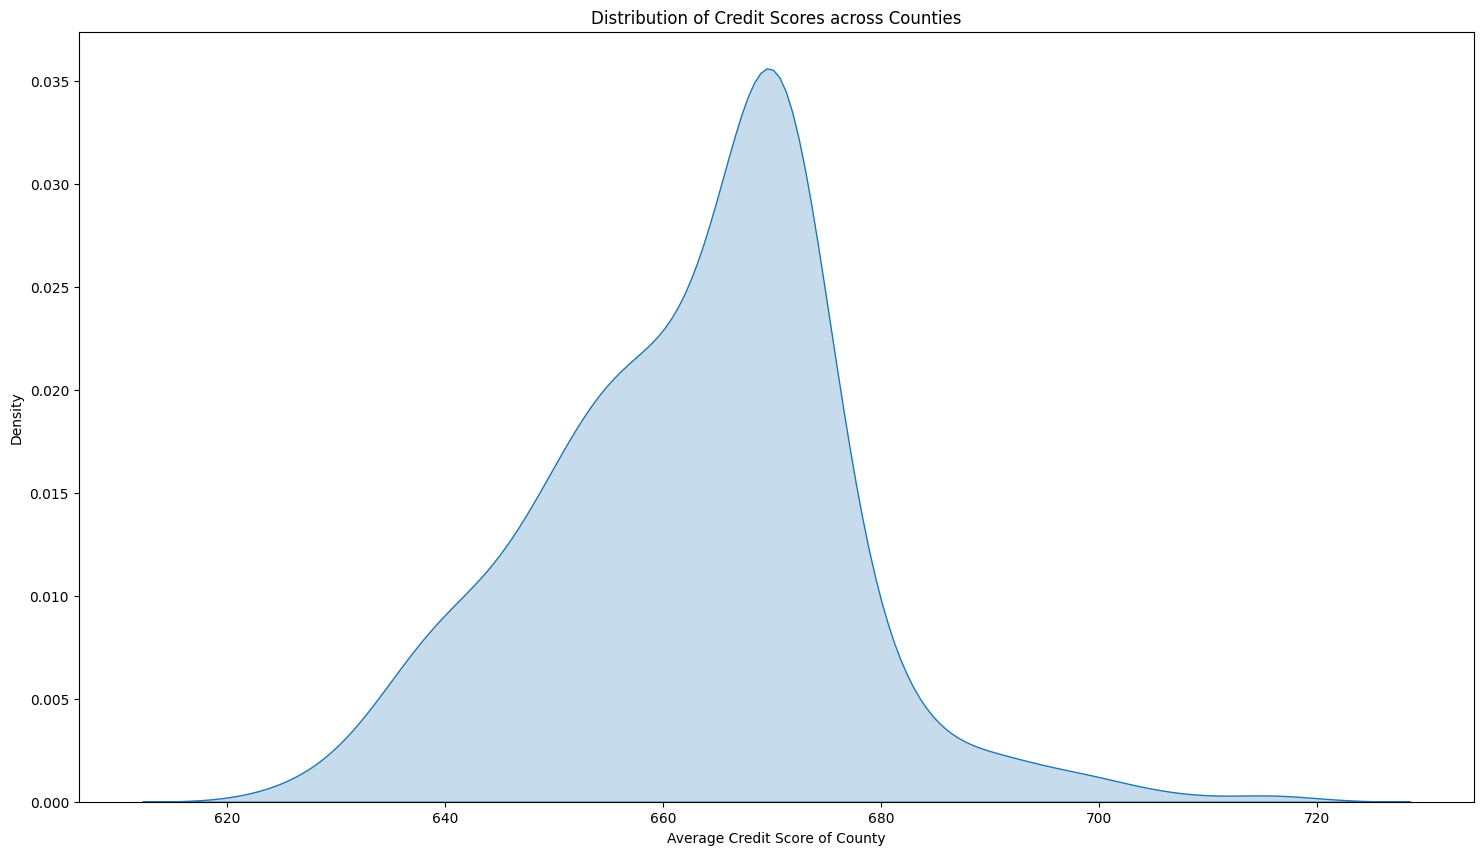

In [46]:
'''
Here, we visualize the distribution of credit scores
'''

sns.kdeplot(data = county_df, x = 'credit_score', fill = True) # Density plot
plt.title('Distribution of Credit Scores across Counties')
plt.xlabel('Average Credit Score of County')
plt.show()

The above plot of credit scores has an almost normal distribution. We see however that there is an obvious rightward skew of the distribution.

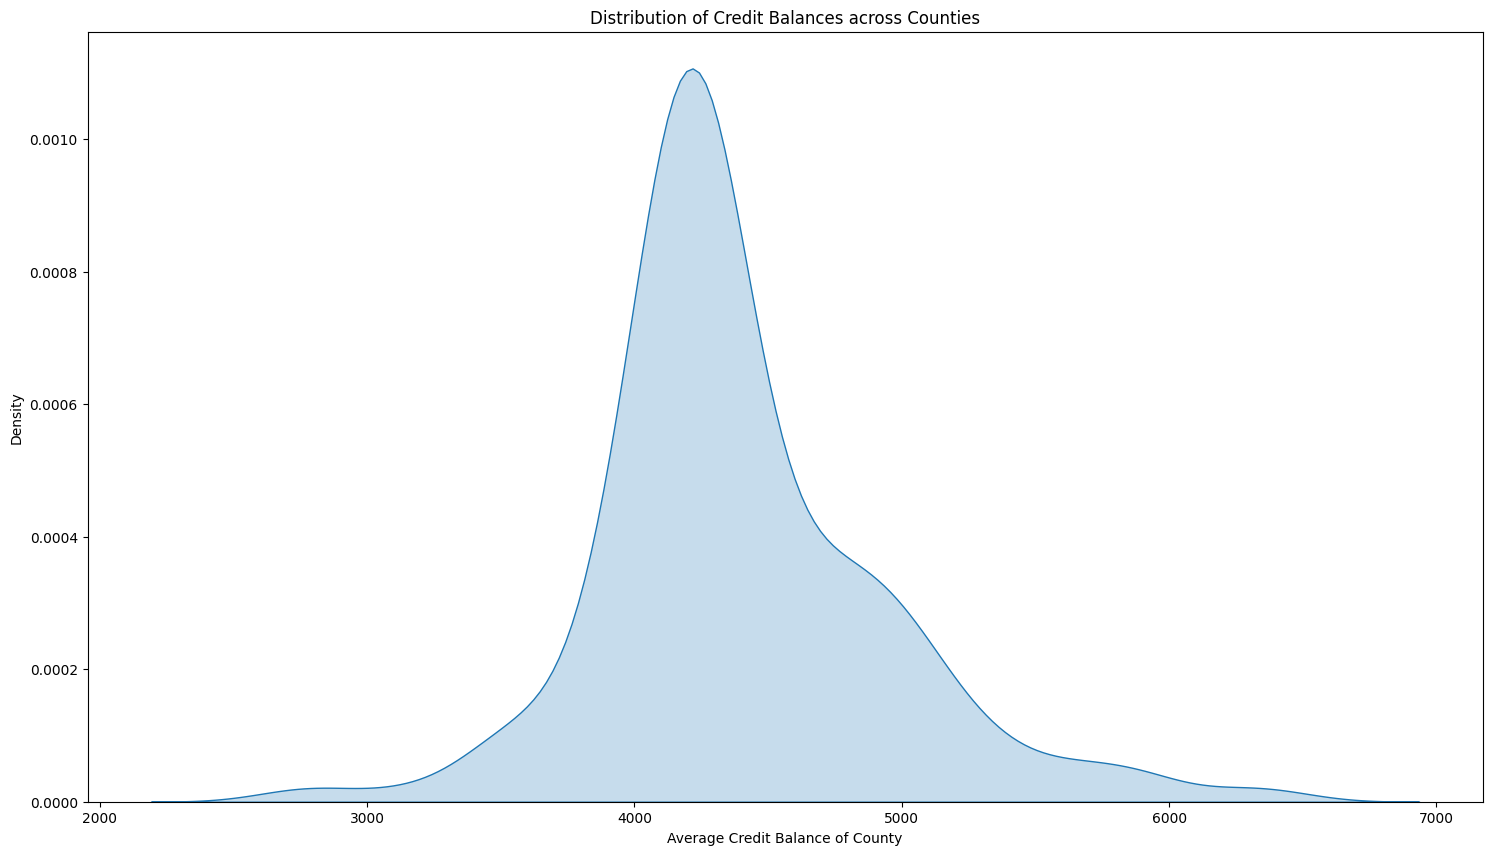

In [47]:
'''
Here, we visualize the distribution of credit balances
'''

sns.kdeplot(data = county_df, x = 'credit_balance', fill = True) # Density plot
plt.title('Distribution of Credit Balances across Counties')
plt.xlabel('Average Credit Balance of County')
plt.show()

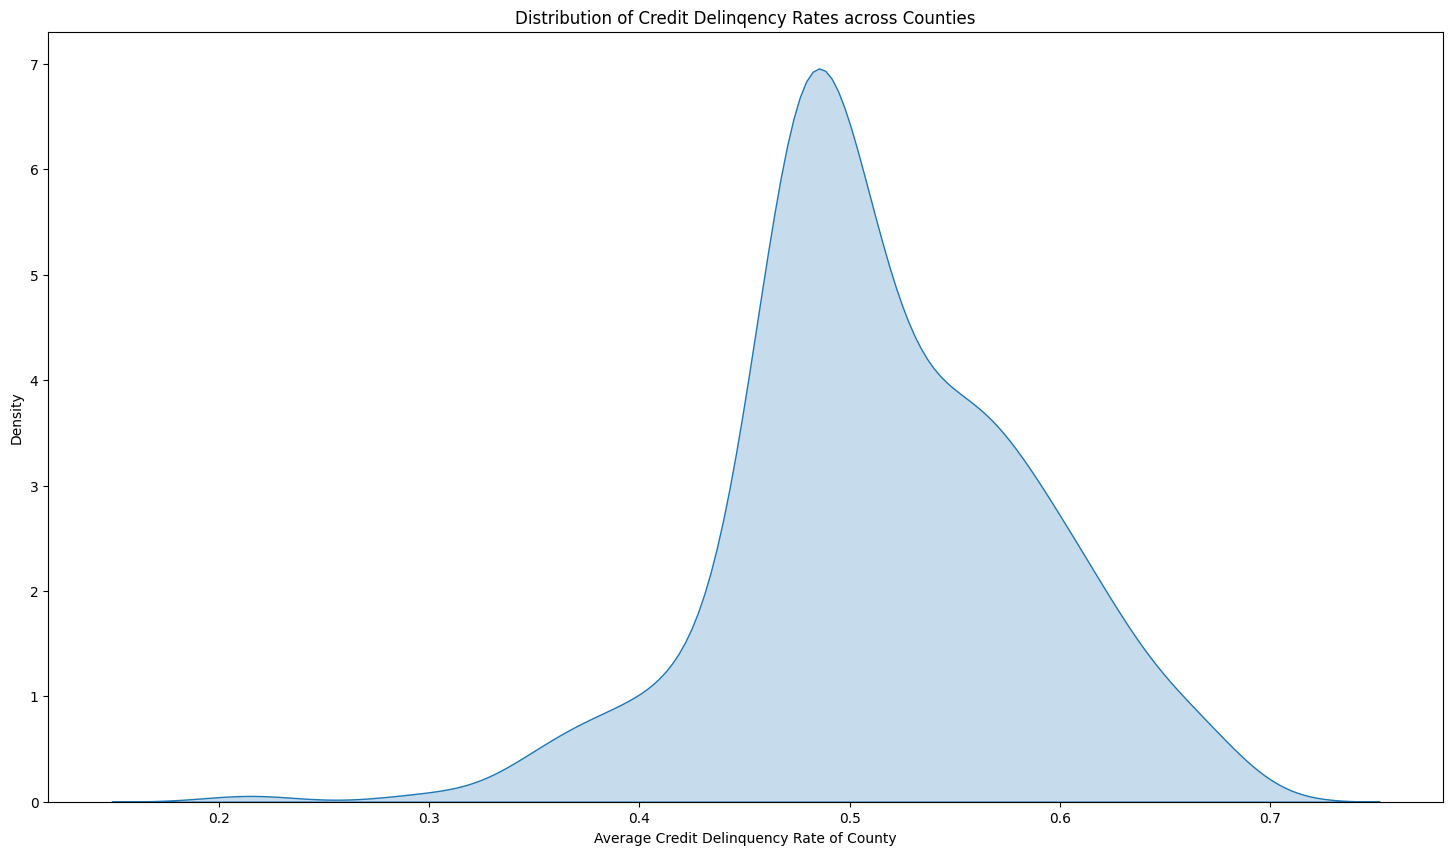

In [48]:
'''
Here, we visualize the distribution of credit delinquency rates
'''

sns.kdeplot(data = county_df, x = 'credit_delinq_rate', fill = True) # Density plot
plt.title('Distribution of Credit Delinqency Rates across Counties')
plt.xlabel('Average Credit Delinquency Rate of County')
plt.show()

The above plot has a very large leftward skew - indicating that there are outliers far below the median.

Now, we will create several scatter plots to observe if there are any associations in the data. 

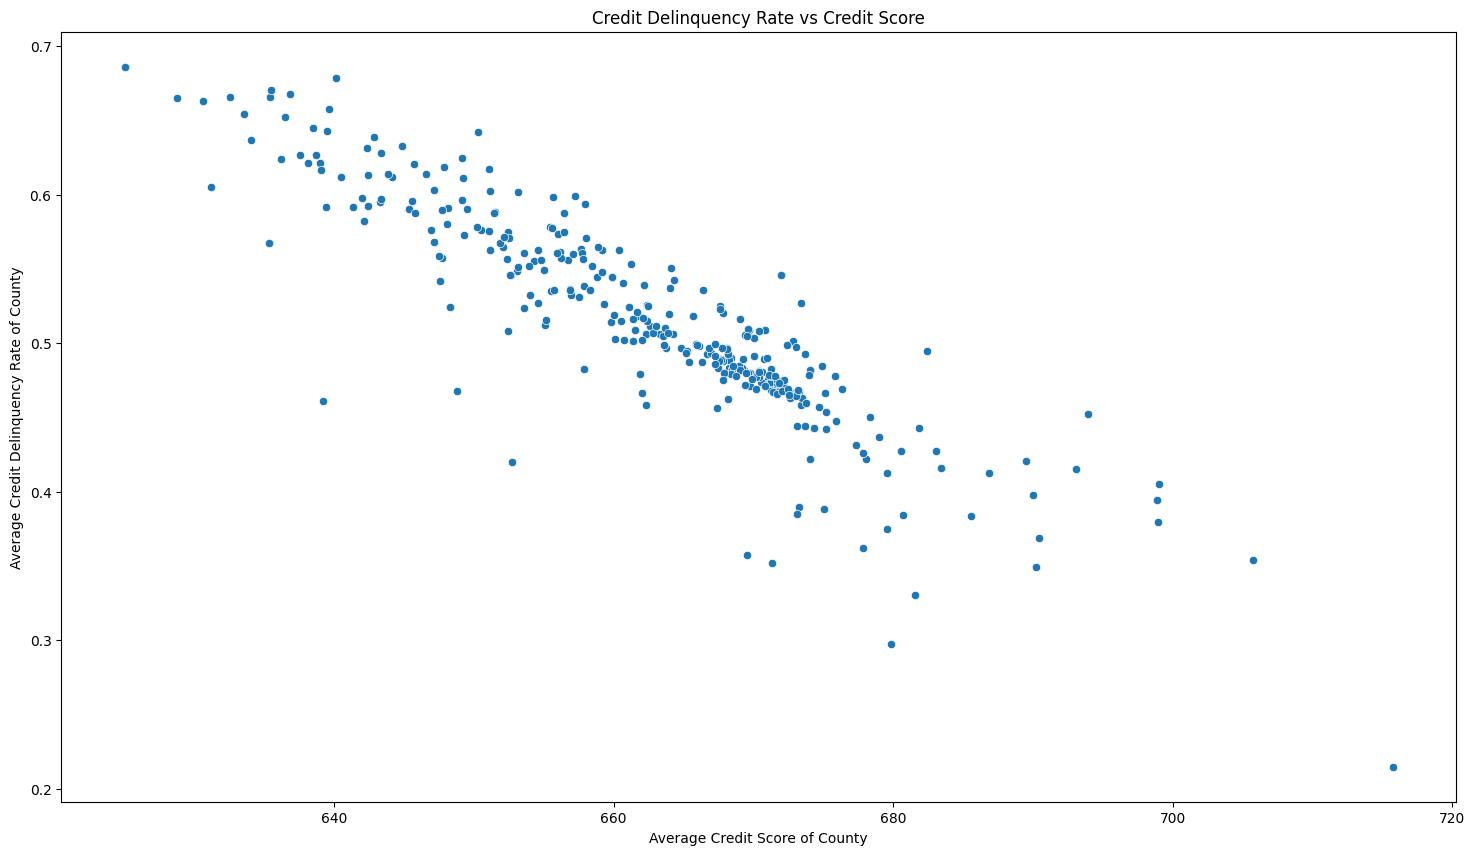

In [49]:
'''
In this scatter plot, we plot the average delinquency rate against the average credit score of a county. We are trying to 
visually observe if there is an association between the two variables.
'''

sns.scatterplot(data = county_df, x = 'credit_score', y = 'credit_delinq_rate') # Scatterplot
plt.title('Credit Delinquency Rate vs Credit Score')
plt.xlabel('Average Credit Score of County')
plt.ylabel('Average Credit Delinquency Rate of County')
plt.show()

In the above scatter plot, we observe what appears to be a strong negative association between the average credit score of a county and the average credit delinquency rate of a county.

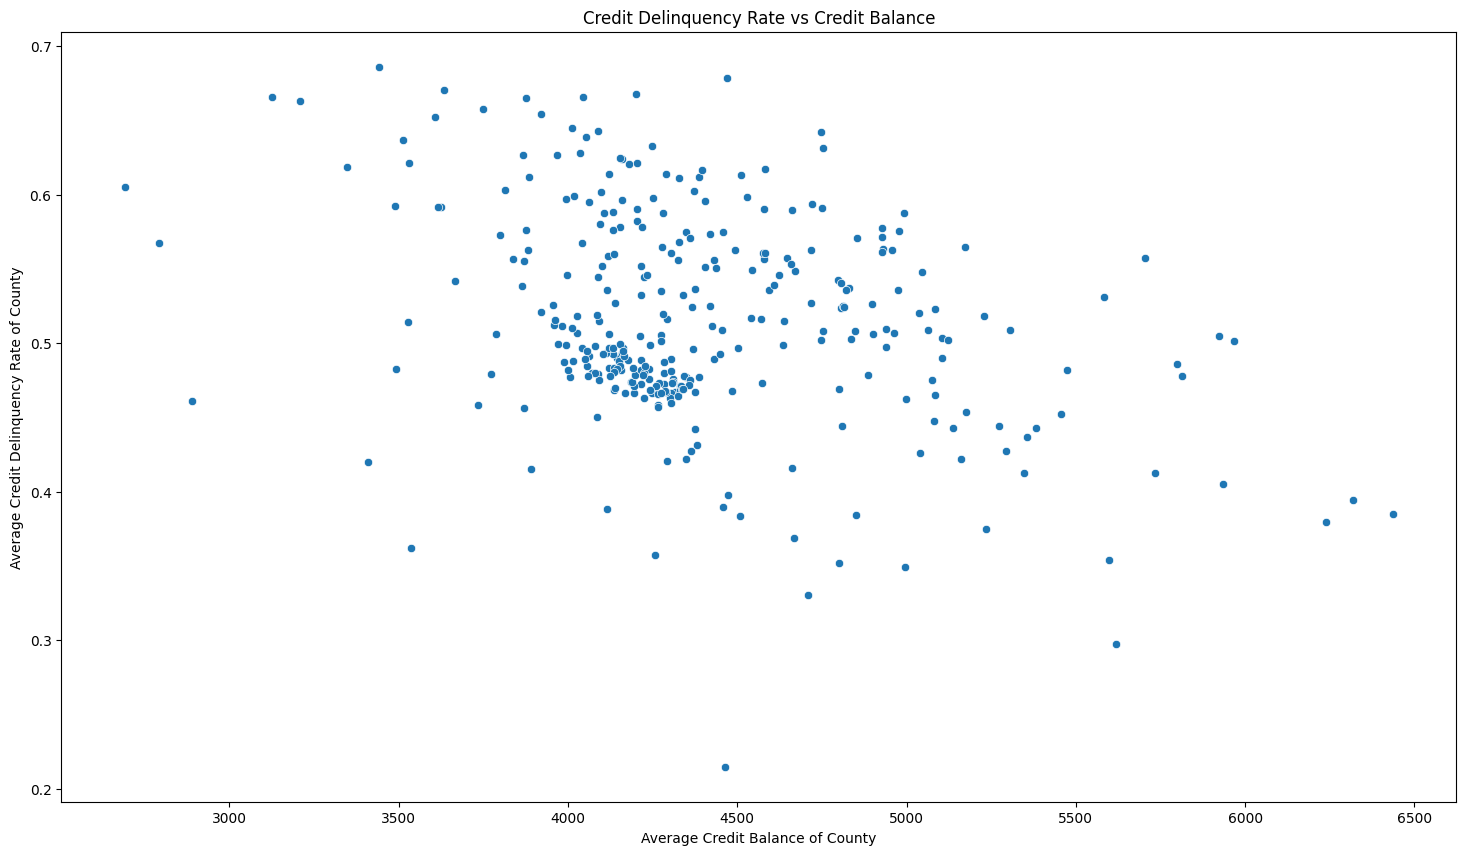

In [50]:
'''
In this scatter plot, we plot the average delinquency rate against the credit card balance of a county. We are trying to 
visually observe if there is an association between the two variables.
'''

sns.scatterplot(data = county_df, x = 'credit_balance', y = 'credit_delinq_rate') # Scatterplot
plt.title('Credit Delinquency Rate vs Credit Balance')
plt.xlabel('Average Credit Balance of County')
plt.ylabel('Average Credit Delinquency Rate of County')
plt.show()

In the above plot, we observe a weak yet noticable negative association between the average credit balance of a county and the average credit delinquency rate of a county. 

However, to understand the true statistcial associations of our data, we must show quantitative findings we calculate. 

***Association Analysis***

In [51]:
import pandas as pd
import scipy.stats as st
import seaborn as sns

In [52]:
#Par_county<>credit_deliq_rate


keys = ['par_state', 'par_county', 'kid_race', 'par_pctile', 'county_name']

df1 = df1.rename(columns={
    'shrunk_xkid_vscore2020': 'credit_score'})
df2 = df2.rename(columns={
    'shrunk_xkid_brcbalance2020': 'credit_balance'
})
df3 = df3.rename(columns={
    'shrunk_xkid_delinq90_02020': 'delinq_rate'
})
# First merge df1 and df2
merged = df1.merge(
    df2,
    on=keys,
    how='inner')

# Merge result with df3
merged = merged.merge(
    df3,
    on=keys,
    how='inner'
)
merged = merged.dropna(subset=['county_name'])

county_race_df = merged.groupby(
    ['par_state', 'par_county', 'county_name', 'kid_race'],
    as_index=False
)[['credit_score', 'credit_balance', 'delinq_rate']].mean()

# Step 3 Drop counties without names (optional cleanup)
county_race_df = county_race_df.dropna(subset=['county_name'])

# Step 4 Inspect the result
county_race_df.head()

,par_state,par_county,county_name,kid_race,credit_score,credit_balance,delinq_rate
0,1,1,Autauga,AIAN,645.200000,3309.000000,0.603450
1,1,1,Autauga,Asian,698.550000,7066.500000,0.424150
2,1,1,Autauga,Black,603.393952,2721.826613,0.724442
3,1,1,Autauga,Hispanic,640.950000,3284.000000,0.564500
4,1,1,Autauga,Pooled,656.947200,3734.748006,0.511261


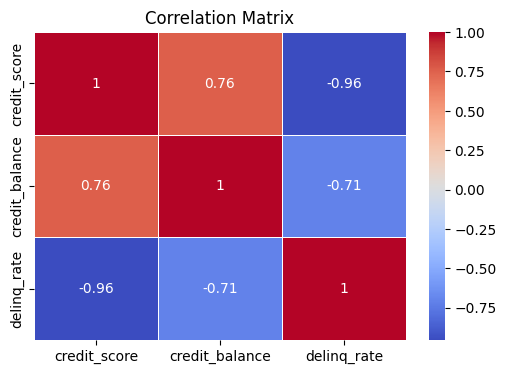

In [53]:
# Here we create a heatmap correlation matrix

plt.figure(figsize=(6,4))
sns.heatmap(
    merged[['credit_score', 'credit_balance', 'delinq_rate']].corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)
plt.title("Correlation Matrix")
plt.show()

I thought it would be smart to initially create a heatmap showing different correlations between different attributes. From this we can inspect a few of the most intriguing pairs of variables.

Right away there are multiple intriguing relationships. Credit_score<>Delinq_rate appears to have a strong negative relationship. credit_balance<>credit_score has a strong relationship and credit_balance<>credit_score appears to have a decently strong negative relationship. I'll be diving further into these relationships and also incorporating the categorical variable kid_race to gain further insights. 

corr: -0.9584827513387182 p-val: 0.0


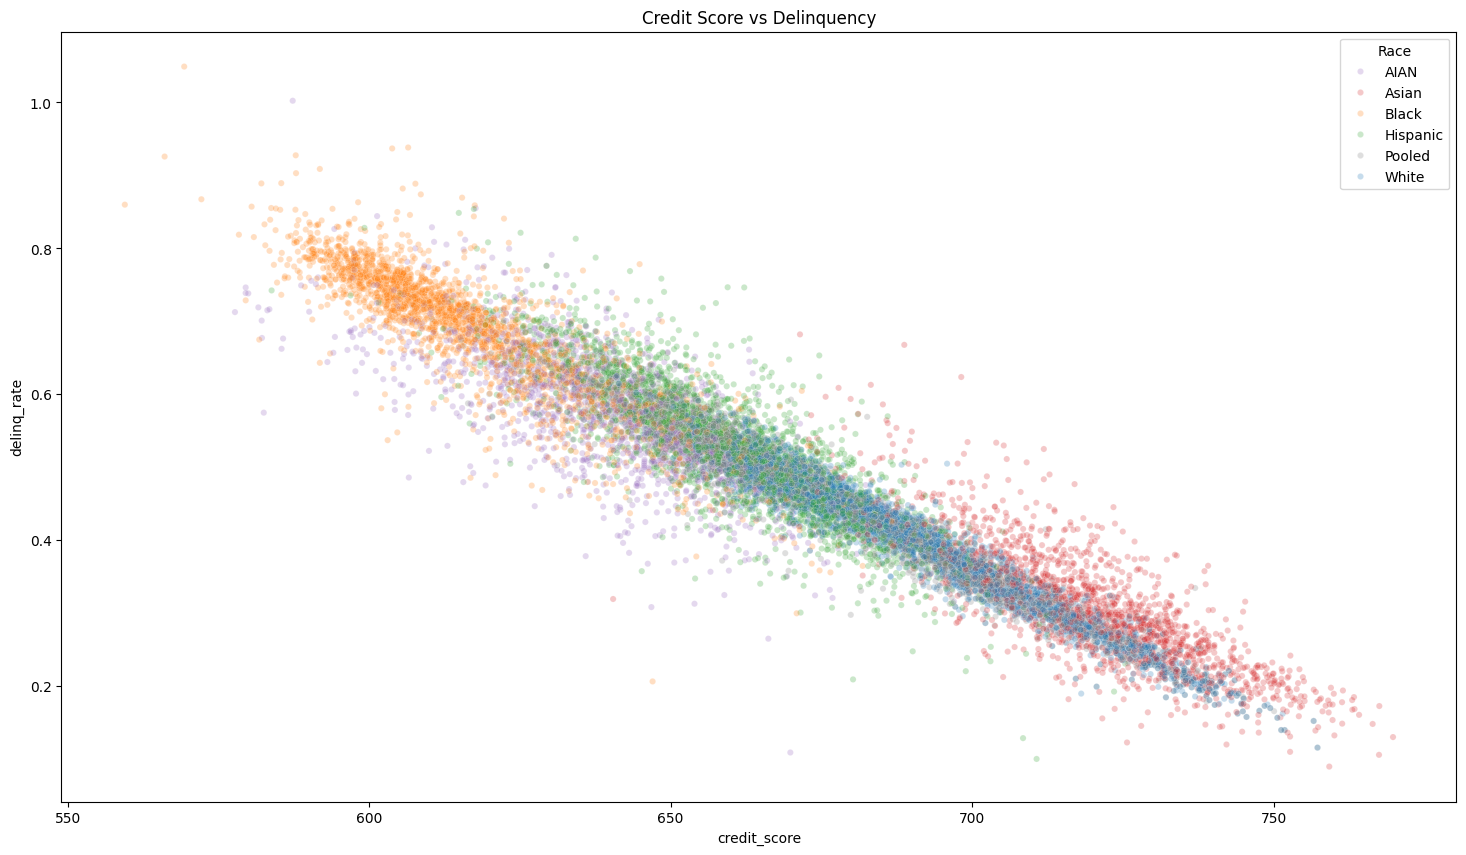

In [54]:
# Here we create a scatter plot showing credit score vs Delinquency color coded by race

''''
The dataset "county_race_df" does not represent individual people or entire counties.
Instead, each row corresponds to a *county–race subgroup*.
This is because we group the merged dataset by:
['par_state', 'par_county', 'county_name', 'kid_race']
and then take the mean of credit_score, credit_balance, and delinq_rate.

example: "the average credit score and average delinquency rate
        for one racial group within one specific county."
'''
county_race_df = county_race_df.dropna(subset=['kid_race'])

corr, pval = st.pearsonr(county_race_df['credit_score'], county_race_df['delinq_rate'])
print("corr:", corr, "p-val:", pval)

race_colors = {
    'White':      '#1f77b4',   
    'Black':      '#ff7f0e',   
    'Hispanic':   '#2ca02c',   
    'Asian':      '#d62728',   
    'AIAN':       '#9467bd',   
    'TwoRace':    '#8c564b','Pooled':     '#7f7f7f'}

sns.scatterplot(
    data=county_race_df,
    x='credit_score',
    y='delinq_rate',
    hue='kid_race',
    palette= race_colors,
    alpha=0.25,
    s=20
)
plt.title("Credit Score vs Delinquency")
plt.legend(title="Race")
plt.show()

corr: 0.7397438556093809 p-val: 0.0


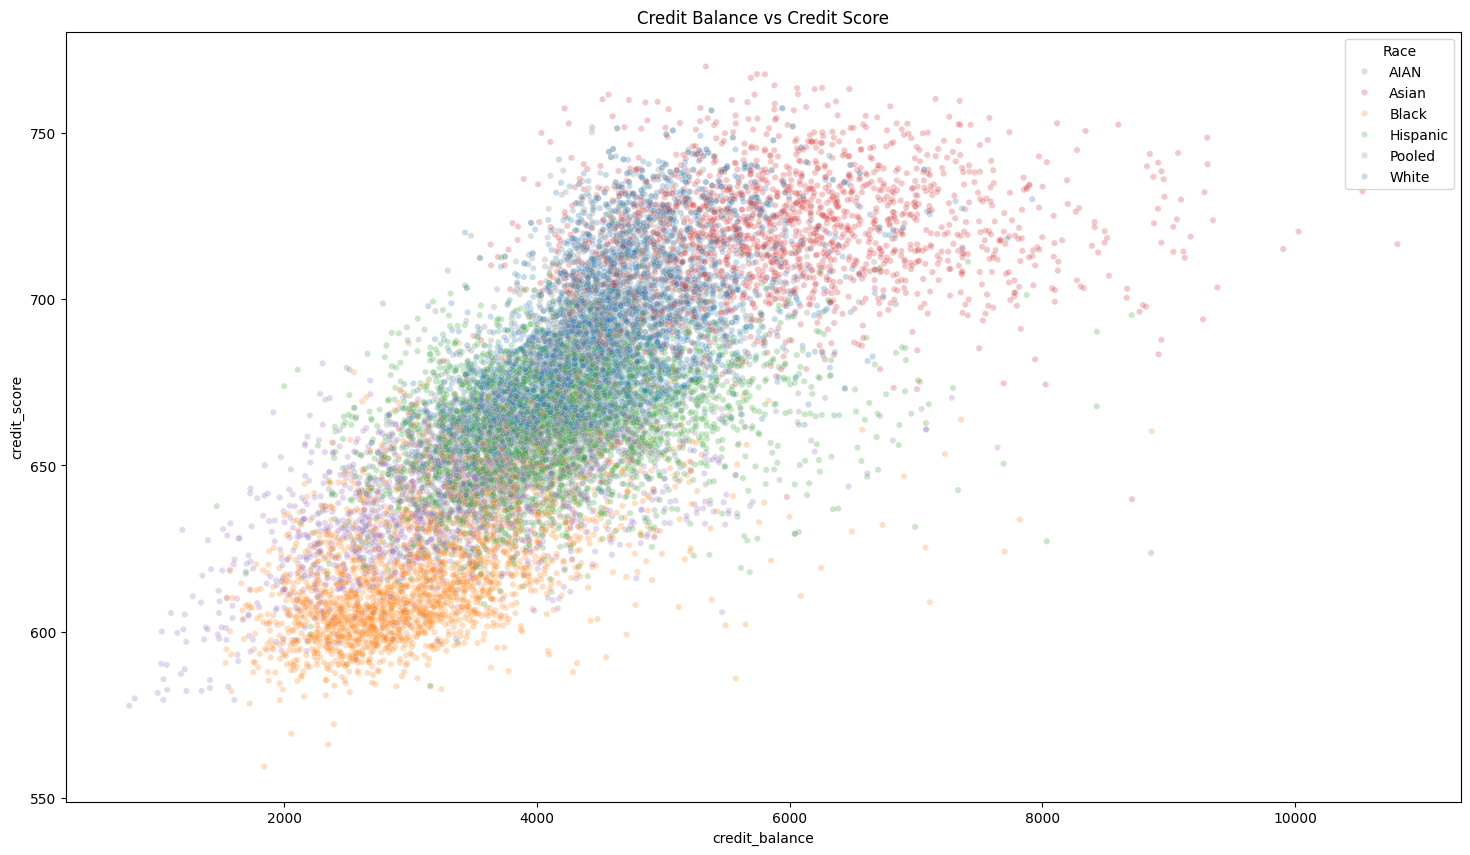

In [55]:
# Here we create a scatter plot showing credit balance vs credit score color coded by race

#credit_balance<>credit_score

county_race_df = county_race_df.dropna(subset=['kid_race'])

corr, pval = st.pearsonr(county_race_df['credit_balance'], county_race_df['credit_score'])
print("corr:", corr, "p-val:", pval)

race_colors = {
    'White':      '#1f77b4',   
    'Black':      '#ff7f0e',   
    'Hispanic':   '#2ca02c',   
    'Asian':      '#d62728',   
    'AIAN':       '#9467bd',  
    'TwoRace':    '#8c564b',
    'Pooled':     '#7f7f7f'
}

sns.scatterplot(
    data=county_race_df,
    x='credit_balance',
    y='credit_score',
    hue='kid_race',
    palette= race_colors,
    alpha=0.25,
    s=20
)
plt.title("Credit Balance vs Credit Score")
plt.legend(title="Race")
plt.show()

corr: -0.6870453316303083 p-val: 0.0


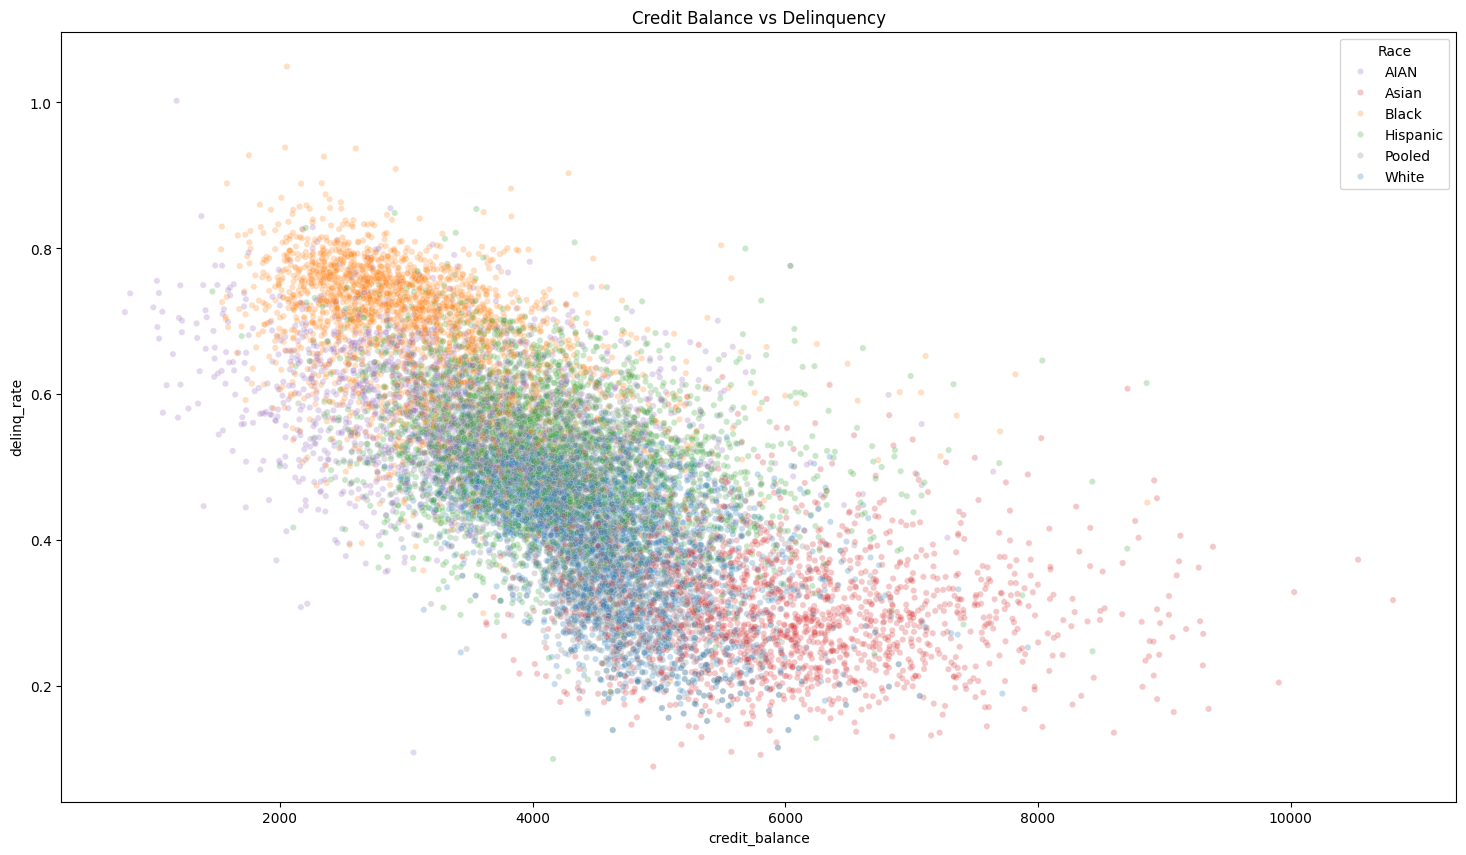

In [56]:
# Here we create a scatter plot showing credit balance vs delinquency color coded by race

#credit_balance<>delinq_rate

county_race_df = county_race_df.dropna(subset=['kid_race'])

corr, pval = st.pearsonr(county_race_df['credit_balance'], county_race_df['delinq_rate'])
print("corr:", corr, "p-val:", pval)

race_colors = {
    'White':      '#1f77b4',   
    'Black':      '#ff7f0e',  
    'Hispanic':   '#2ca02c',  
    'Asian':      '#d62728',   
    'AIAN':       '#9467bd',   
    'TwoRace':    '#8c564b',
    'Pooled':     '#7f7f7f'
}

sns.scatterplot(
    data=county_race_df,
    x='credit_balance',
    y='delinq_rate',
    hue='kid_race',
    palette= race_colors,
    alpha=0.25,
    s=20
)
plt.title("Credit Balance vs Delinquency")
plt.legend(title="Race")
plt.show()

All three graphs are interesting, especially when you consider the dots being color coded by race. 

As expected, Credit Score vs Delinquency clearly has the strongest relationship, the heatmap and correlation coefficient values proved true in this scenario. Lets dive further into this relationship by now considering counties. Since there are 1847 counties in the data, we'll just display the top 5 and bottom 5 counties that appear in the plot. 

In [57]:
min_score = county_race_df['credit_score'].min()
max_delinq = county_race_df['delinq_rate'].max()

max_score = county_race_df['credit_score'].max()
min_delinq = county_race_df['delinq_rate'].min()

county_race_df['dist_upper_left'] = (
    (county_race_df['credit_score'] - min_score)**2 +
    (county_race_df['delinq_rate'] - max_delinq)**2)

county_race_df['dist_bottom_right'] = (
    (county_race_df['credit_score'] - max_score)**2 +
    (county_race_df['delinq_rate'] - min_delinq)**2)

upper_left_5 = county_race_df.nsmallest(5, 'dist_upper_left')
bottom_right_5 = county_race_df.nsmallest(5, 'dist_bottom_right')

print("5 UPPER-LEFT POINTS (Low Score + High Delinquency)")
print(upper_left_5[['county_name','credit_score','delinq_rate','kid_race']])

print("5 BOTTOM-RIGHT POINTS (High Score + Low Delinquency)")
print(bottom_right_5[['county_name','credit_score','delinq_rate','kid_race']])

5 UPPER-LEFT POINTS (Low Score + High Delinquency)
      county_name  credit_score  delinq_rate kid_race
11825      Castro    559.450000     0.859850    Black
11950     Dickens    566.050000     0.925850    Black
12763     Wheeler    569.300000     1.049250    Black
1659        Dixie    572.150000     0.867250    Black
486        Graham    577.717857     0.712482     AIAN
5 BOTTOM-RIGHT POINTS (High Score + Low Delinquency)
                county_name  credit_score  delinq_rate kid_race
8462               New York    769.823810     0.129559    Asian
9002                 Orange    767.550379     0.172131    Asian
13472  Charlottesville City    767.500000     0.105205    Asian
5622                Norfolk    766.448188     0.147567    Asian
11763                Brazos    764.193382     0.160055    Asian


We identify the upper-left corner as the county with the lowest credit score and highest delinquency, and the bottom-right corner as the county with the highest credit score and lowest delinquency.
Then we measure how close each county is to each of those two corners by comparing how far its credit score and delinquency values are from the corner values.
Finally, we pick the five counties that are closest to each corner, giving us the top five and bottom five points on the plot. Visually, what I've done is the same plot as above, but with only the ten most important dots. I've displayed it below. 

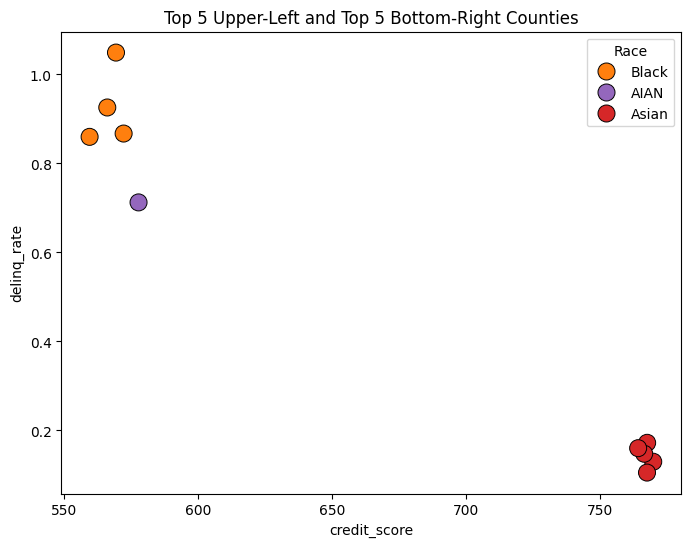

In [58]:
# Here we find the counties that have the most extreme values of credit score vs delinquency rate by racial group in counties. The we plot them.

county_race_df = county_race_df.dropna(subset=['kid_race']) # dropping na from kid_race

race_colors = {
    'White':      '#1f77b4',
    'Black':      '#ff7f0e',
    'Hispanic':   '#2ca02c',
    'Asian':      '#d62728',
    'AIAN':       '#9467bd',
    'TwoRace':    '#8c564b',
    'Pooled':     '#7f7f7f'
}

# max and min vals
min_score = county_race_df['credit_score'].min()
max_delinq = county_race_df['delinq_rate'].max()

max_score = county_race_df['credit_score'].max()
min_delinq = county_race_df['delinq_rate'].min()

# squared difference
county_race_df['dist_upper_left'] = (
    (county_race_df['credit_score'] - min_score)**2 +
    (county_race_df['delinq_rate'] - max_delinq)**2
)

county_race_df['dist_bottom_right'] = (
    (county_race_df['credit_score'] - max_score)**2 +
    (county_race_df['delinq_rate'] - min_delinq)**2
)

# Selecting extreme counties
upper_left_5 = county_race_df.nsmallest(5, 'dist_upper_left')
bottom_right_5 = county_race_df.nsmallest(5, 'dist_bottom_right')

highlight_10 = pd.concat([upper_left_5, bottom_right_5])

# Plotting extreme counties
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=highlight_10,
    x='credit_score',
    y='delinq_rate',
    hue='kid_race',
    palette=race_colors,
    s=150,      
    edgecolor='black',
    linewidth=0.7
)

plt.title("Top 5 Upper-Left and Top 5 Bottom-Right Counties")
plt.legend(title="Race")
plt.show()

***Predictive Modeling***

For our predictive modeling section, we choose to employ a decision tree to predict the delinquency rate of a county/

In [59]:
# Libraries

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn import metrics, tree

In [60]:
# Calculating median of county level credit delinquency
median_delinq = county_df['credit_delinq_rate'].median()

# Creating a binary column to indicate delinquency
county_df['delinq_class'] = (county_df['credit_delinq_rate'] > median_delinq).astype(int)

# 1 = high delinquency, 0 = low delinquency
county_df.head()

,par_county,credit_score,credit_balance,credit_delinq_rate,delinq_class
0,1,671.519952,4286.560883,0.468026,0
1,3,673.281987,4315.248830,0.467079,0
2,5,671.752389,4303.661005,0.466196,0
3,6,663.751545,4501.633122,0.496967,0
4,7,671.263061,4136.151462,0.468444,0


In [61]:
labels = county_df['delinq_class']       # class label to predict
attrs = county_df.drop(['delinq_class'], axis=1) # getting features to use in prediction by dropping the class label

labels.head(), attrs.head() # Displaying the first couple of rows of data


(0    0
 1    0
 2    0
 3    0
 4    0
 Name: delinq_class, dtype: int64,
    par_county  credit_score  credit_balance  credit_delinq_rate
 0           1    671.519952     4286.560883            0.468026
 1           3    673.281987     4315.248830            0.467079
 2           5    671.752389     4303.661005            0.466196
 3           6    663.751545     4501.633122            0.496967
 4           7    671.263061     4136.151462            0.468444)

In [62]:
# Creating train and test sets
x_train, x_test, y_train, y_test = train_test_split(
    attrs, labels, 
    test_size=0.2, # 20% of data will be used for testing
    random_state=42
)

print("x_train:", x_train.shape, "y_train:", y_train.shape)
print("x_test:", x_test.shape, "y_test:", y_test.shape)

x_train: (264, 4) y_train: (264,)
x_test: (66, 4) y_test: (66,)


In [63]:
# Creating decision tree 
clf = DecisionTreeClassifier(min_samples_split=10, random_state=42)

# Fitting the model to training data
clf.fit(x_train, y_train)

# Predicting labels using the test set
y_pred = clf.predict(x_test)

# Evaluating accuracy
acc = metrics.accuracy_score(y_test, y_pred)
print("Decision Tree accuracy:", acc)

Decision Tree accuracy: 1.0


The above decision tree classifier model has an accuracy of 1.0 - indicating extreme overfitting of the model. This is because we include the actual delinquency rate as a variable to be trained on (something which our target is derived from). However, this model is not a waste as it shows at a simple level how the decision tree model is created and used. 

[Text(0.5, 0.75, 'credit_delinq_rate <= 0.504\ngini = 0.5\nsamples = 264\nvalue = [129, 135]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 129\nvalue = [129, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 135\nvalue = [0, 135]'),
 Text(0.625, 0.5, '  False')]

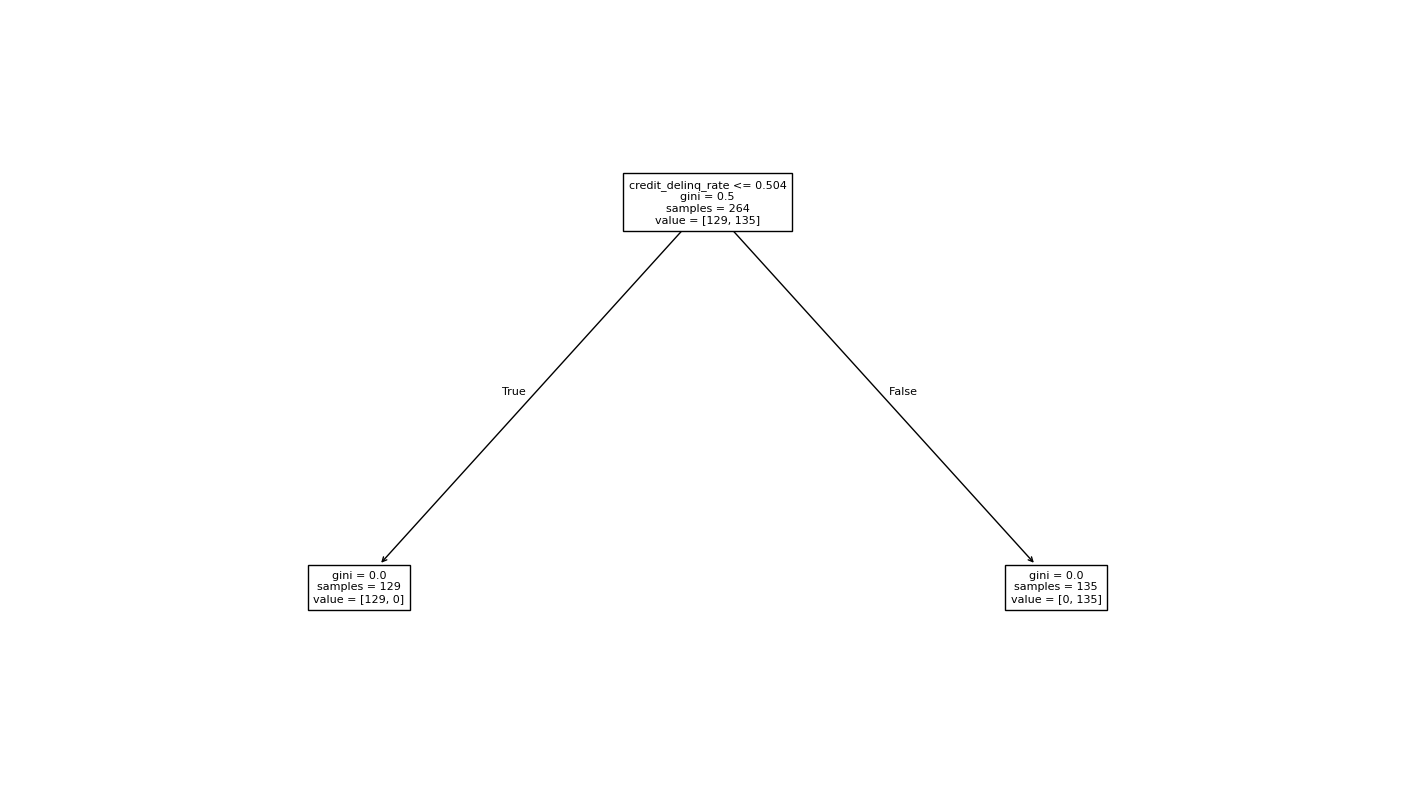

In [64]:
# Plotting the tree
plt.rcParams["figure.figsize"] = (18, 10)
tree.plot_tree(clf, fontsize=8, feature_names=list(attrs.columns))

In [65]:
# Creating a new decision tree classifer. Here we will not use the delinquency rate and instead rely on the other features we have.

attrs_harder = county_df.drop(columns=['delinq_class', 'credit_delinq_rate'])

# train and test sets
x_train, x_test, y_train, y_test = train_test_split(
    attrs_harder, labels, test_size=0.2, random_state=42
)

# fitting to train sets
clf = DecisionTreeClassifier(min_samples_split=10, random_state=42)
clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)

# Evaluating accuracy
acc_harder = metrics.accuracy_score(y_test, y_pred)
print("Harder-model accuracy:", acc_harder)

Harder-model accuracy: 0.9242424242424242


This decision tree has a lower accuracy of 0.924. However, this model is better because it does not use the actual delinquency rate as a predictor. We believe that this new decision tree classifier is a strong model because it can predict whether the delinquency rate of a county is high or low with an accuracy of 92%.

[Text(0.4868421052631579, 0.9285714285714286, 'credit_score <= 664.547\ngini = 0.5\nsamples = 264\nvalue = [129, 135]'),
 Text(0.23684210526315788, 0.7857142857142857, 'credit_score <= 660.087\ngini = 0.152\nsamples = 133\nvalue = [11, 122]'),
 Text(0.3618421052631579, 0.8571428571428572, 'True  '),
 Text(0.10526315789473684, 0.6428571428571429, 'credit_balance <= 3502.461\ngini = 0.057\nsamples = 103\nvalue = [3, 100]'),
 Text(0.05263157894736842, 0.5, 'gini = 0.346\nsamples = 9\nvalue = [2, 7]'),
 Text(0.15789473684210525, 0.5, 'par_county <= 193.0\ngini = 0.021\nsamples = 94\nvalue = [1, 93]'),
 Text(0.10526315789473684, 0.35714285714285715, 'gini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.21052631578947367, 0.35714285714285715, 'gini = 0.0\nsamples = 92\nvalue = [0, 92]'),
 Text(0.3684210526315789, 0.6428571428571429, 'credit_balance <= 3779.407\ngini = 0.391\nsamples = 30\nvalue = [8, 22]'),
 Text(0.3157894736842105, 0.5, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.4210

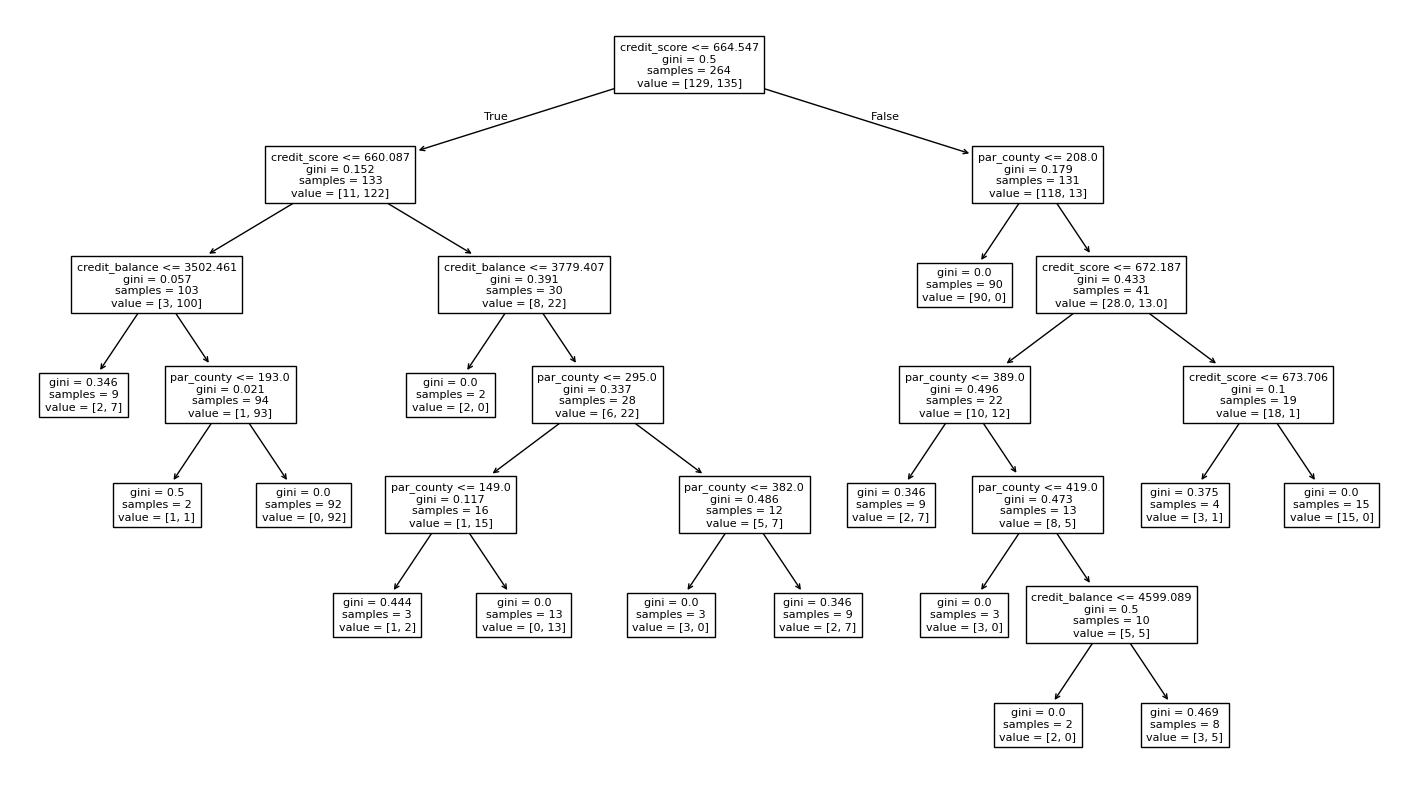

In [66]:
# Plotting the new tree
plt.rcParams["figure.figsize"] = (18, 10)
tree.plot_tree(clf, fontsize=8, feature_names=list(attrs_harder.columns))

***Conclusion***

    We constructed a classification model to identify whether a county exhibits high or low delinquency rate using a median split to create a binary class label. From here the decision tree classifier was trained on the predictors: average credit score, credit card balance, delinquency rate and county identifier. The initial (“easier”) model achieved strong performance because of the inclusion of delinquency rate. This is because the binary classifier label is directly derived from the delinquency rate. Although there is obvious overfitting and lack of predictive value, this model is still important because it showcases how a decision tree model is created and evaluated. We then wanted to take our model to the next step by making it “harder”. By following the framework used in Lab 8 and removing the raw delinquency rate used to construct the class label, the model would be forced to rely only on the remaining predictors: credit score, credit balance and county. As we already knew, credit score and credit balance strongly correlate with delinquency, this was reflected once again when the tree used these variables mainly to create the structure of the tree. The overall accuracy declined to 0.92, understandable as the model no longer has access to the exact delinquency values and must infer class membership from other predictors. This model has more predictive importance, as it can predict whether the delinquency rate of a county is high or low with 92% accuracy. Overall the harder model still reinforces a key insight from analyses: financial characteristics remain the dominant factors associated with county-level delinquency patterns, even when more direct information is removed from the model. 

    Some interesting insights we uncovered through our analysis were that delinquency and credit score were both heavily correlated. They had a strong negative relationship, meaning that a higher delinquency is associated with a lower credit score. Adding race as a dimension to the visualizations of the data shows how access to credit (as well as delinquency and balance) is distributed across races.

    Some ideas for future exploration of the data are determining how credit score and access to credit affects quality of life. This is important because quality of life is directly linked to crime and health outcomes. If we can determine that there is a link between access to credit and quality of life, we can find out ways to help people - thus improving societal outcomes.